# Comunas + Censo 2024

Cruce territorial basico usando `codigo_comuna` como llave estable.

In [1]:
# Instala chile-hub si el entorno no lo trae (p. ej. Google Colab)
try:
    import chile_hub  # noqa: F401
except ImportError:
    %pip install -q chile-hub

In [2]:
from chile_hub import ChileHub

hub = ChileHub()
comunas = hub.load_polars("comunas")
censo = hub.load_polars("censo_comunal")

In [3]:
ranking = (
    comunas.join(censo, on="codigo_comuna")
    .select("codigo_comuna", "nombre_comuna", "nombre_region", "poblacion_censada")
    .sort("poblacion_censada", descending=True)
    .head(15)
)
ranking

codigo_comuna,nombre_comuna,nombre_region,poblacion_censada
str,str,str,i64
"""13201""","""Puente Alto""","""Región Metropolitana de Santia…",568086
"""13119""","""Maipú""","""Región Metropolitana de Santia…",503635
"""13101""","""Santiago""","""Región Metropolitana de Santia…",438856
"""02101""","""Antofagasta""","""Región de Antofagasta""",401096
"""13110""","""La Florida""","""Región Metropolitana de Santia…",374836
…,…,…,…
"""10101""","""Puerto Montt""","""Región de Los Lagos""",277040
"""04102""","""Coquimbo""","""Región de Coquimbo""",263719
"""06101""","""Rancagua""","""Región del Libertador Bernardo…",257744


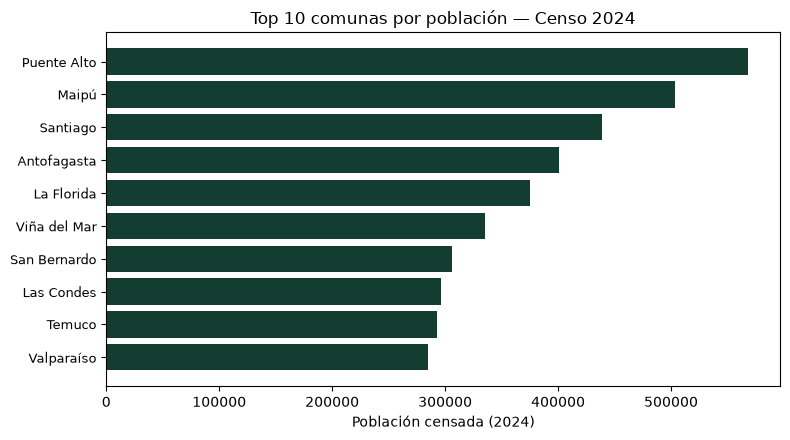

In [4]:
# Gráfico: top 10 comunas por población censada
import matplotlib.pyplot as plt

top10 = ranking.head(10).sort("poblacion_censada")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top10["nombre_comuna"], top10["poblacion_censada"], color="#123d30")
ax.set_xlabel("Población censada (2024)")
ax.set_title("Top 10 comunas por población — Censo 2024")
ax.tick_params(axis="y", labelsize=9)
fig.tight_layout()
plt.show()